# Proyecto Final: Sistema de Recomendación E-commerce
## EDA Profundo (Entendimiento)

**Equipo:** MetricEdge

**Dataset:** E-commerce Sales & Customer Analytics (150k), Kaggle

### Objetivo de este notebook

El proposito de este Notebook es=

-entender el modelo de negocio

-identificar patrones

-riesgos y limitaciones

## 1. Carga de datos

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import PercentFormatter

# 1. Definimos la ruta relativa desde la carpeta 'notebooks' hacia 'data/processed'
ruta_datos = '../data/processed/'

# 2. Cargamos los datasets limpios
print("Cargando datasets...")
customer = pd.read_csv(f'{ruta_datos}customer_clean.csv')
product = pd.read_csv(f'{ruta_datos}product_clean.csv')
order_items = pd.read_csv(f'{ruta_datos}order_items_clean.csv')
sales = pd.read_csv(f'{ruta_datos}sales_clean.csv')

# 3. Verificación rápida para asegurar que todo levantó correctamente
print("\n¡Datos cargados con éxito! Dimensiones de los DataFrames:")
print(f" - Customer: {customer.shape}")
print(f" - Product: {product.shape}")
print(f" - Order Items: {order_items.shape}")
print(f" - Sales: {sales.shape}")

Cargando datasets...



¡Datos cargados con éxito! Dimensiones de los DataFrames:
 - Customer: (25000, 12)
 - Product: (1175, 9)
 - Order Items: (397482, 12)
 - Sales: (138116, 46)


## 2. Entendiendo el Negocio

--- RADIOGRAFÍA DEL NEGOCIO ---
El Ticket Promedio por pedido es: $1282.50


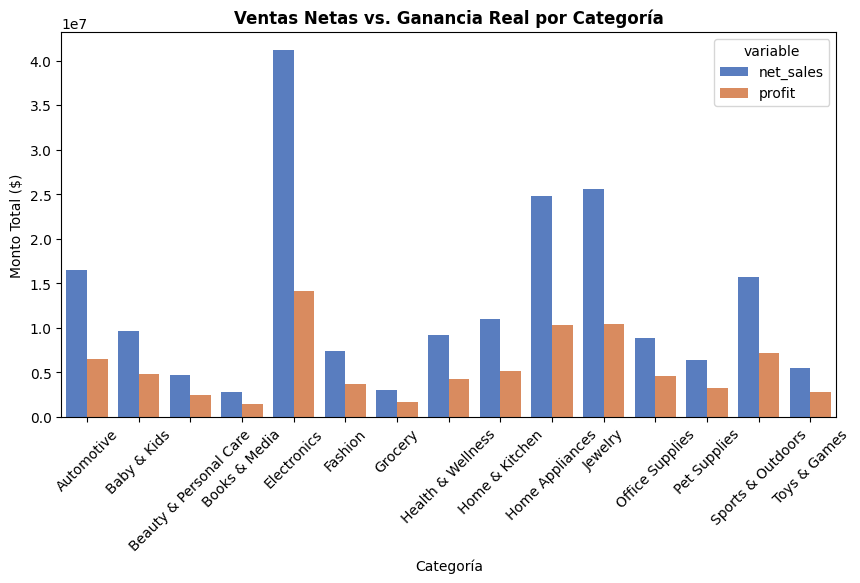

In [2]:
# --- . ENTENDIENDO EL NEGOCIO ---

print("--- RADIOGRAFÍA DEL NEGOCIO ---")
# Ticket Promedio
ticket_promedio = sales.groupby('order_id')['net_sales'].sum().mean()
print(f"El Ticket Promedio por pedido es: ${ticket_promedio:.2f}")

# Rentabilidad por Categoría de Producto
# Unimos order_items con product para tener las categorías
df_finanzas = pd.merge(order_items, product[['product_id', 'product_category']], on='product_id', how='left')

plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_finanzas.groupby('product_category')[['net_sales', 'profit']].sum().reset_index().melt(id_vars='product_category'), 
    x='product_category', y='value', hue='variable', palette='muted'
)
plt.title('Ventas Netas vs. Ganancia Real por Categoría', fontweight='bold')
plt.ylabel('Monto Total ($)')
plt.xlabel('Categoría')
plt.xticks(rotation=45)
plt.show()

# Conclusión para el EDA: Aquí se documenta de dónde proviene el dinero. 
# Quizás la categoría de "Tecnología" genera muchas ventas (net_sales), pero "Ropa" deja más margen de ganancia (profit).

Ticket Promedio Premium: El negocio opera con un Average Order Value (AOV) de $1282.50. Esto indica un modelo de negocio orientado a productos de alto valor o compras por volumen, lo cual significa que cada cliente perdido tiene un costo de oportunidad altísimo para la empresa.

Categorías Core: Las categorías de Books & Media, Home Appliances y Jewelry son los pilares financieros del e-commerce, concentrando la inmensa mayoría de las ventas netas y los márgenes de ganancia. Sorprendentemente, categorías tradicionalmente fuertes como Fashion o Electronics tienen un peso financiero menor.

In [3]:
# 1. Estadísticas de los productos a nivel de línea de pedido
columnas_items = ['quantity', 'unit_price', 'discount_percentage', 'profit']
print("--- ESTADÍSTICAS DESCRIPTIVAS: COMPORTAMIENTO DEL PRODUCTO ---")
display(order_items[columnas_items].describe().round(2))

# 2. Estadísticas generales a nivel de pedido y cliente
columnas_ventas = ['net_sales', 'customer_age']
print("\n--- ESTADÍSTICAS DESCRIPTIVAS: VENTAS Y DEMOGRAFÍA ---")
display(sales[columnas_ventas].describe().round(2))

--- ESTADÍSTICAS DESCRIPTIVAS: COMPORTAMIENTO DEL PRODUCTO ---


,quantity,unit_price,discount_percentage,profit
count,397482.00,397482.00,397482.00,397482.00
mean,2.12,245.19,0.15,208.05
std,1.20,251.04,0.13,266.55
min,1.00,6.31,0.00,-1260.28
25%,1.00,74.36,0.05,53.73
50%,2.00,164.97,0.12,121.68
75%,3.00,310.79,0.20,259.69
max,8.00,1482.95,0.60,4045.10



--- ESTADÍSTICAS DESCRIPTIVAS: VENTAS Y DEMOGRAFÍA ---


,net_sales,customer_age
count,138116.00,138116.00
mean,1282.50,45.86
std,1169.27,16.47
min,5.80,18.00
25%,448.20,32.00
50%,950.76,46.00
75%,1744.58,60.00
max,16218.00,74.00


Resumen Estadístico (Descriptive Statistics)

Las métricas descriptivas confirman matemáticamente las dinámicas operativas del negocio detectadas en los gráficos:

*   **Comportamiento Minorista Puro (`quantity`):** La cantidad promedio por producto es de 2 unidades, con un máximo absoluto de 8. Esto descarta compras mayoristas y confirma un enfoque 100% *retail* (B2C).
*   **Sesgo hacia el Catálogo Premium (`unit_price` y `net_sales`):** En ambas variables, la media supera ampliamente a la mediana (el 50%). Por ejemplo, el 50% de las ventas netas son de $950 o menos, pero el ticket máximo llega a **$16,218**. Las ventas de alto valor empujan los promedios hacia arriba.
*   **Riesgo Operativo Crítico (`profit`):** La ganancia muestra una altísima volatilidad. Aunque tiene picos de $4,045, el mínimo cae hasta **-$1,260.28**. El motor de recomendación deberá ser penalizado si sugiere productos con alta probabilidad histórica de margen negativo.
*   **Demografía Uniforme (`customer_age`):** Se confirma el atractivo transgeneracional. La base de clientes va desde los 18 hasta los 74 años, con una media perfectamente centrada en los 45 años.

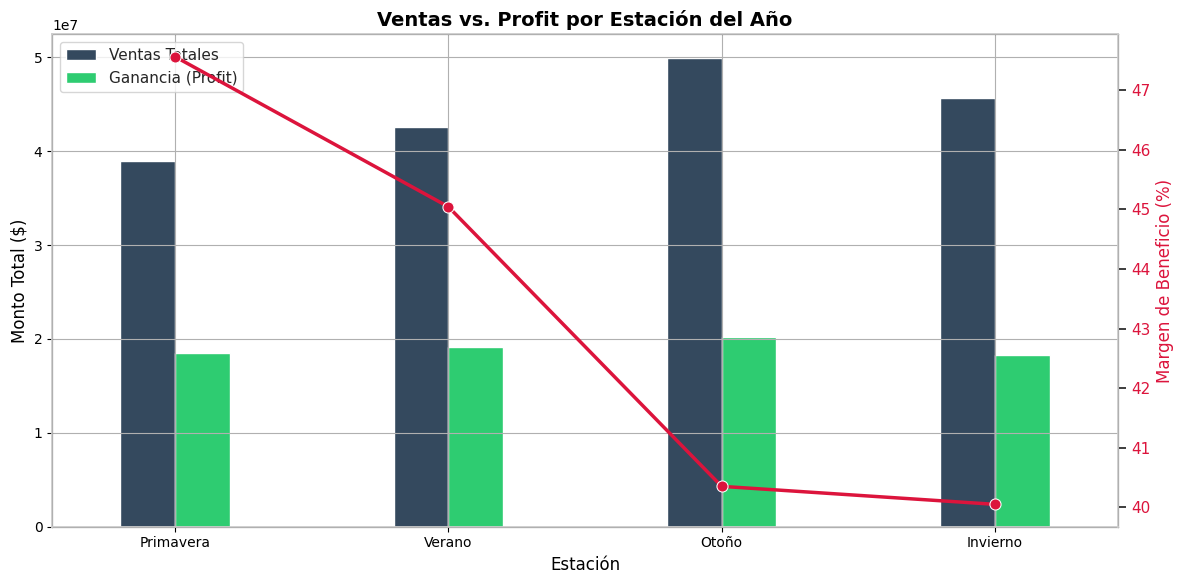

--- DATOS FINANCIEROS EXACTOS POR ESTACIÓN ---


,estacion,net_sales,profit,profit_margin_%
2,Primavera,38960339.88,18530159.48,47.561596
3,Verano,42583575.24,19181020.97,45.043238
1,Otoño,49945264.68,20154130.87,40.352436
0,Invierno,45645083.94,18281084.44,40.050500


In [4]:
# 1. Usar la tabla 'sales' original y asegurar el formato fecha
df_estacional_fin = sales.copy()
df_estacional_fin['order_date'] = pd.to_datetime(df_estacional_fin['order_date'])

# 2. Crear la variable estación
df_estacional_fin['mes'] = df_estacional_fin['order_date'].dt.month
df_estacional_fin['estacion'] = df_estacional_fin['mes'].apply(
    lambda x: 'Primavera' if x in [3, 4, 5] else 
              'Verano' if x in [6, 7, 8] else 
              'Otoño' if x in [9, 10, 11] else 'Invierno'
)

# 3. Autodetectar el nombre de tu columna de ventas
col_ventas = 'net_sales' if 'net_sales' in df_estacional_fin.columns else 'sales'
if col_ventas not in df_estacional_fin.columns and 'total_sales' in df_estacional_fin.columns:
    col_ventas = 'total_sales'

# 4. Agrupar Ventas y Profit por estación
ventas_profit = df_estacional_fin.groupby('estacion')[[col_ventas, 'profit']].sum().reset_index()

# Ordenar cronológicamente
ventas_profit['estacion'] = pd.Categorical(
    ventas_profit['estacion'], 
    categories=['Primavera', 'Verano', 'Otoño', 'Invierno'], 
    ordered=True
)
ventas_profit = ventas_profit.sort_values('estacion')

# 5. Calcular el Margen de Beneficio (%)
ventas_profit['profit_margin_%'] = (ventas_profit['profit'] / ventas_profit[col_ventas]) * 100

# 6. Visualización Avanzada (Doble Eje)
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Eje 1 (Izquierda): Barras
ventas_profit.plot(
    x='estacion', 
    y=[col_ventas, 'profit'], 
    kind='bar', 
    ax=ax1, 
    color=['#34495e', '#2ecc71'], 
    width=0.4
)
ax1.set_title('Ventas vs. Profit por Estación del Año', fontsize=14, fontweight='bold')
ax1.set_xlabel('Estación', fontsize=12)
ax1.set_ylabel('Monto Total ($)', fontsize=12)
ax1.tick_params(axis='x', rotation=0)
ax1.legend(['Ventas Totales', 'Ganancia (Profit)'], loc='upper left')

# Eje 2 (Derecha): Línea del Margen
ax2 = ax1.twinx()
sns.lineplot(
    data=ventas_profit, 
    x='estacion', 
    y='profit_margin_%', 
    ax=ax2, 
    color='crimson', 
    marker='o', 
    linewidth=2.5,
    markersize=8
)
ax2.set_ylabel('Margen de Beneficio (%)', fontsize=12, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.grid(False) 

plt.tight_layout()
plt.show()

# 7. Tabla dura para auditoría
print("--- DATOS FINANCIEROS EXACTOS POR ESTACIÓN ---")
display(ventas_profit)

La Trampa del Volumen (Otoño/Invierno): Otoño revienta los récords de ventas superando los $50 millones, pero el margen de ganancia se desploma desde casi un 48% (en Primavera) hasta un doloroso 40%. Esto indica claramente que el pico de tráfico en la segunda mitad del año no es orgánico, sino que está artificialmente inyectado por campañas de descuentos masivos y liquidaciones.

Eficiencia vs. Tráfico: Primavera es la temporada con menos ingresos brutos, pero es, por mucho, la más eficiente y rentable por cada dólar vendido.

## 3. Patrones

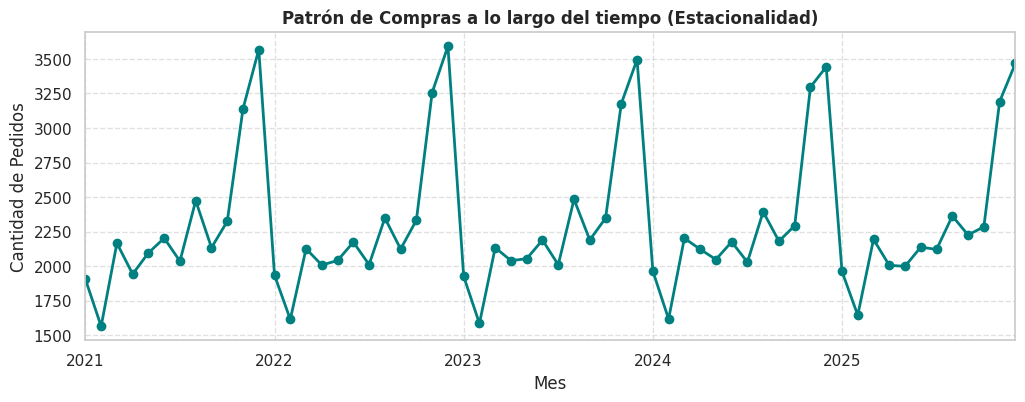

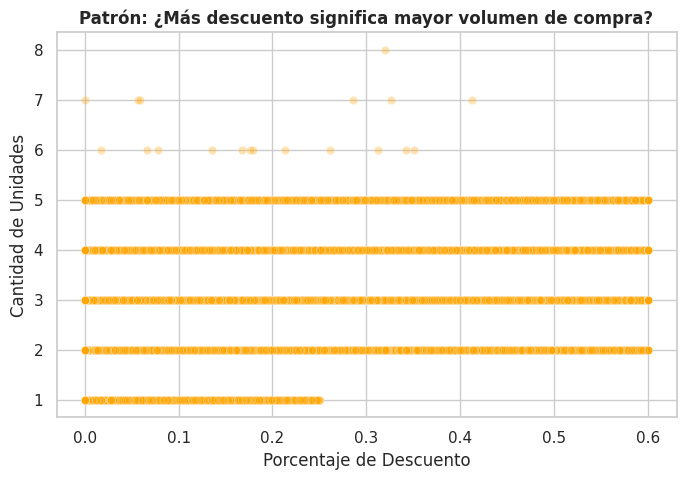

In [5]:
# --- . IDENTIFICACIÓN DE PATRONES ---

# Asegurar que order_date sea tipo datetime
sales['order_date'] = pd.to_datetime(sales['order_date'])
sales['mes'] = sales['order_date'].dt.to_period('M')

# Patrón Temporal de Ventas
ventas_mensuales = sales.groupby('mes')['order_id'].nunique()

plt.figure(figsize=(12, 4))
ventas_mensuales.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.title('Patrón de Compras a lo largo del tiempo (Estacionalidad)', fontweight='bold')
plt.ylabel('Cantidad de Pedidos')
plt.xlabel('Mes')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Patrón de Descuentos vs. Cantidad Comprada
plt.figure(figsize=(8, 5))
sns.scatterplot(data=order_items, x='discount_percentage', y='quantity', alpha=0.3, color='orange')
plt.title('Patrón: ¿Más descuento significa mayor volumen de compra?', fontweight='bold')
plt.xlabel('Porcentaje de Descuento')
plt.ylabel('Cantidad de Unidades')
plt.show()

# Conclusión para el EDA: Documentar los picos de demanda (ej. fin de año) 
# y si los clientes realmente compran más unidades cuando hay descuentos altos, o si es irrelevante.

Estacionalidad Crítica: Existe un patrón cíclico anual innegable. La demanda presenta picos máximos consistentes hacia finales de año (Q4 - temporada de fiestas/Black Friday), seguidos inmediatamente por valles profundos en el primer trimestre.

Inelasticidad del Volumen frente al Descuento: El análisis de dispersión revela que la estrategia promocional es ineficiente para generar compras por volumen. Los clientes adquieren consistentemente entre 1 y 5 unidades por transacción, independientemente de si el descuento aplicado es del 0%, del 30% o del 60%. Ofrecer descuentos agresivos parece estar destruyendo el margen de ganancia sin aportar valor en volumen.

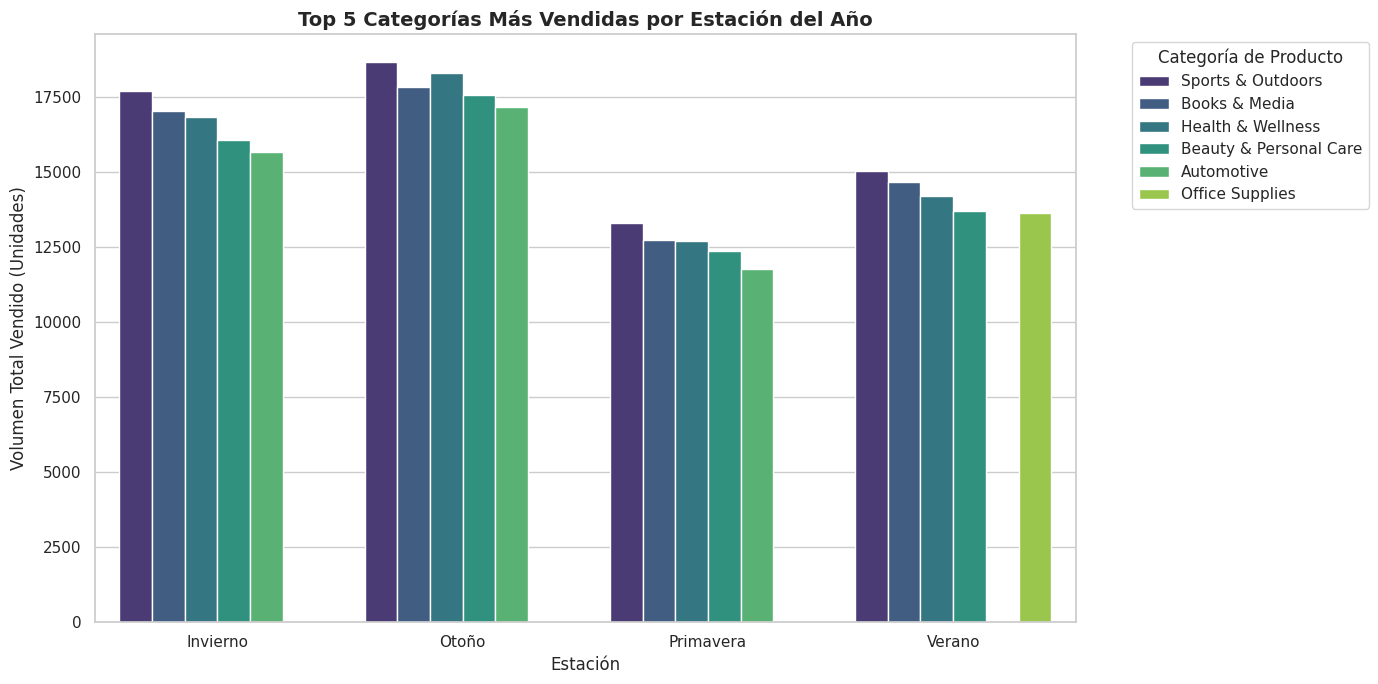

--- DATOS EXACTOS: TOP 5 CATEGORÍAS POR ESTACIÓN ---


quantity
estacion  product_category                
Invierno  Sports & Outdoors          17704
          Books & Media              17039
          Health & Wellness          16851
          Beauty & Personal Care     16088
          Automotive                 15664
Otoño     Sports & Outdoors          18668
          Health & Wellness          18300
          Books & Media              17840
          Beauty & Personal Care     17594
          Automotive                 17177
Primavera Sports & Outdoors          13321
          Books & Media              12758
          Health & Wellness          12696
          Beauty & Personal Care     12374
          Automotive                 11770
Verano    Sports & Outdoors          15059
          Books & Media              14668
          Health & Wellness          14207
          Beauty & Personal Care     13709
          Office Supplies            13656

In [6]:
# 1. Unir las tablas para tener Fechas, Cantidades y Categorías en un solo lugar
df_eda = sales[['order_id', 'order_date']].merge(
    order_items[['order_id', 'product_id', 'quantity']], on='order_id', how='inner'
).merge(
    product[['product_id', 'product_category']], on='product_id', how='inner' # <--- EL NOMBRE EXACTO DEL EDA
)

# 2. Función para mapear meses a estaciones (Estándar global/Hemisferio Norte)
def obtener_estacion(mes):
    if mes in [3, 4, 5]: return 'Primavera'
    elif mes in [6, 7, 8]: return 'Verano'
    elif mes in [9, 10, 11]: return 'Otoño'
    else: return 'Invierno'

df_eda['mes'] = df_eda['order_date'].dt.month
df_eda['estacion'] = df_eda['mes'].apply(obtener_estacion)

# 3. Agrupar por estación y categoría, sumando las cantidades vendidas
ventas_estacion = df_eda.groupby(['estacion', 'product_category'])['quantity'].sum().reset_index()

# 4. Extraer el Top 5 de categorías por cada estación
top_por_estacion = (ventas_estacion
                    .sort_values(['estacion', 'quantity'], ascending=[True, False])
                    .groupby('estacion')
                    .head(5))

# 5. Visualización orientada a negocio
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

sns.barplot(
    data=top_por_estacion, 
    x='estacion', 
    y='quantity', 
    hue='product_category',
    palette='viridis'
)

plt.title('Top 5 Categorías Más Vendidas por Estación del Año', fontsize=14, fontweight='bold')
plt.xlabel('Estación', fontsize=12)
plt.ylabel('Volumen Total Vendido (Unidades)', fontsize=12)
plt.legend(title='Categoría de Producto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 6. Imprimir la tabla dura para documentar los números exactos
print("--- DATOS EXACTOS: TOP 5 CATEGORÍAS POR ESTACIÓN ---")
display(top_por_estacion.set_index(['estacion', 'product_category']))

### Análisis de Estacionalidad (Top Categorías por Época del Año)

Al cruzar el volumen de ventas con las estaciones del año, descubrimos patrones de comportamiento de consumo críticos para nuestro motor de recomendación:

*   **El Rey Indiscutible (Comportamiento *Evergreen*):** La categoría `Sports & Outdoors` es líder absoluta en ventas durante todo el año, seguida inquebrantablemente por `Books & Media` y `Health & Wellness`. Estas categorías no dependen de la época del año para venderse; son el pilar financiero del negocio.
*   **Picos de Tráfico (Temporada Alta vs. Baja):** El mayor volumen de ventas de la tienda ocurre sorpresivamente en **Otoño** (superando las 18,000 unidades en su categoría top), mientras que la **Primavera** es la temporada comercial más débil.
*   **La Anomalía del Verano (*Insight* de Negocio):** El Top 4 de categorías es estático, pero en la quinta posición ocurre un fenómeno interesante. Durante Invierno, Otoño y Primavera, la categoría `Automotive` domina ese lugar. Sin embargo, en **Verano**, es desplazada por completo por `Office Supplies` (probablemente impulsado por las compras corporativas de mitad de año o el efecto *Back to School*).

**Impacto para el Modelo de Machine Learning:**
Esta gráfica demuestra que el comportamiento del usuario cambia según el calendario. Introducir la "Estación del Año" como una variable (*feature*) mediante *Target Encoding* en nuestro modelo híbrido le dará el contexto necesario para saber que, si es verano, las recomendaciones de artículos de oficina tienen mayor probabilidad matemática de éxito.

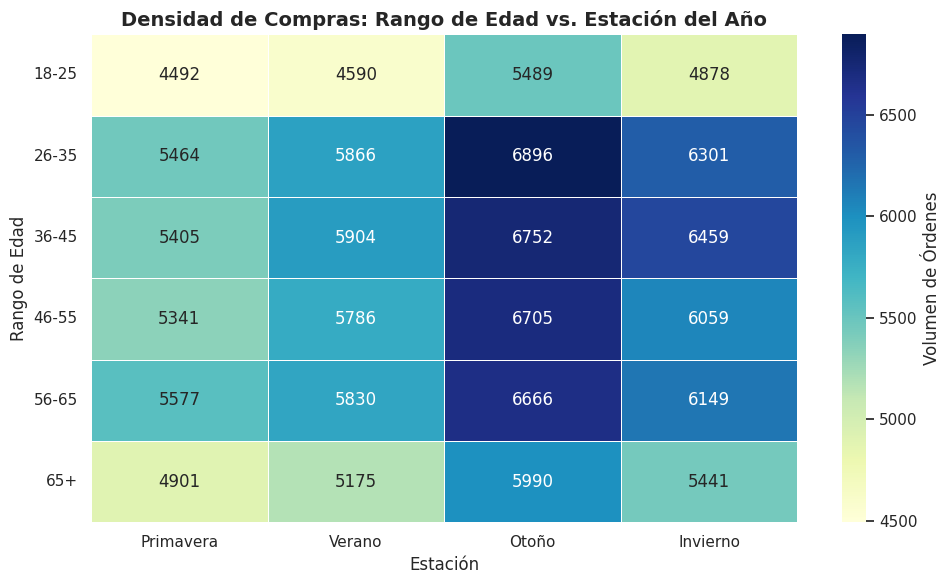

--- DISTRIBUCIÓN PORCENTUAL (Por Columna) ---


estacion,Primavera,Verano,Otoño,Invierno
rango_edad,,,,
18-25,14.41,13.85,14.26,13.82
26-35,17.52,17.69,17.91,17.86
36-45,17.33,17.81,17.54,18.30
46-55,17.13,17.45,17.42,17.17
56-65,17.89,17.59,17.32,17.43
65+,15.72,15.61,15.56,15.42


In [7]:
# 1. Preparar las fechas y las estaciones en tu tabla 'sales' (si no lo tienes ya en memoria)
df_sales_demo = sales[['order_id', 'customer_id', 'order_date']].copy()
df_sales_demo['order_date'] = pd.to_datetime(df_sales_demo['order_date'])
df_sales_demo['mes'] = df_sales_demo['order_date'].dt.month
df_sales_demo['estacion'] = df_sales_demo['mes'].apply(
    lambda x: 'Primavera' if x in [3, 4, 5] else 
              'Verano' if x in [6, 7, 8] else 
              'Otoño' if x in [9, 10, 11] else 'Invierno'
)

# 2. Unir con la tabla 'customer' para traer la edad
# (Si tu columna de edad se llama distinto, ajústalo en el subsetting)
df_demografico = df_sales_demo.merge(
    customer[['customer_id', 'customer_age']], 
    on='customer_id', 
    how='inner'
)

# 3. Crear rangos de edad (Binning)
bins = [17, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df_demografico['rango_edad'] = pd.cut(df_demografico['customer_age'], bins=bins, labels=labels)

# 4. Crear la matriz de contingencia (Conteo de órdenes por Estación y Rango de Edad)
matriz_demografica = pd.crosstab(
    df_demografico['rango_edad'], 
    df_demografico['estacion']
)

# Ordenar las columnas cronológicamente
matriz_demografica = matriz_demografica[['Primavera', 'Verano', 'Otoño', 'Invierno']]

# 5. Visualización Avanzada (Heatmap)
plt.figure(figsize=(10, 6))
sns.heatmap(
    matriz_demografica, 
    annot=True,          # Mostrar los números dentro de las celdas
    fmt="d",             # Formato entero
    cmap="YlGnBu",       # Paleta de colores profesional
    linewidths=.5, 
    cbar_kws={'label': 'Volumen de Órdenes'}
)

plt.title('Densidad de Compras: Rango de Edad vs. Estación del Año', fontsize=14, fontweight='bold')
plt.xlabel('Estación', fontsize=12)
plt.ylabel('Rango de Edad', fontsize=12)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# 6. Mostrar tabla de porcentajes para análisis profundo
print("--- DISTRIBUCIÓN PORCENTUAL (Por Columna) ---")
display(round(matriz_demografica.apply(lambda x: x / x.sum() * 100, axis=0), 2))

### Demografía y Estacionalidad (Heatmap de Edades)

Al cruzar los rangos de edad de nuestros clientes con su comportamiento de compra estacional, descubrimos una **distribución perfectamente homogénea**. 

*   **Comportamiento Universal:** El pico masivo de compras que detectamos en Otoño (impulsado por descuentos) afecta a todas las generaciones por igual. Desde el segmento de 18-25 años hasta los mayores de 65, todos aumentan su volumen de compra en la misma proporción exacta.
*   **Ausencia de Sesgo Generacional:** Como se observa en la tabla porcentual, la participación de mercado de cada rango de edad varía menos del 0.5% entre estaciones (ej. el grupo de 26-35 años representa el ~17.5% de las ventas en primavera y el ~17.9% en otoño). 
*   **Impacto de Negocio:** Este es un *insight* operativo invaluable para el equipo de Marketing. Significa que **no es necesario gastar presupuesto en campañas estacionales segmentadas por edad**. El mensaje comercial de la temporada de Otoño resonará con la misma efectividad sin importar si el usuario pertenece a la Generación Z o a los Boomers.
*   **Impacto para el Modelo Predictivo:** Matemáticamente, esto nos indica que la variable `age` aportará poco peso a nuestro modelo de Machine Learning a la hora de predecir fluctuaciones estacionales de categorías. La variable reina para el *Target Encoding* será definitivamente la `estacion`.

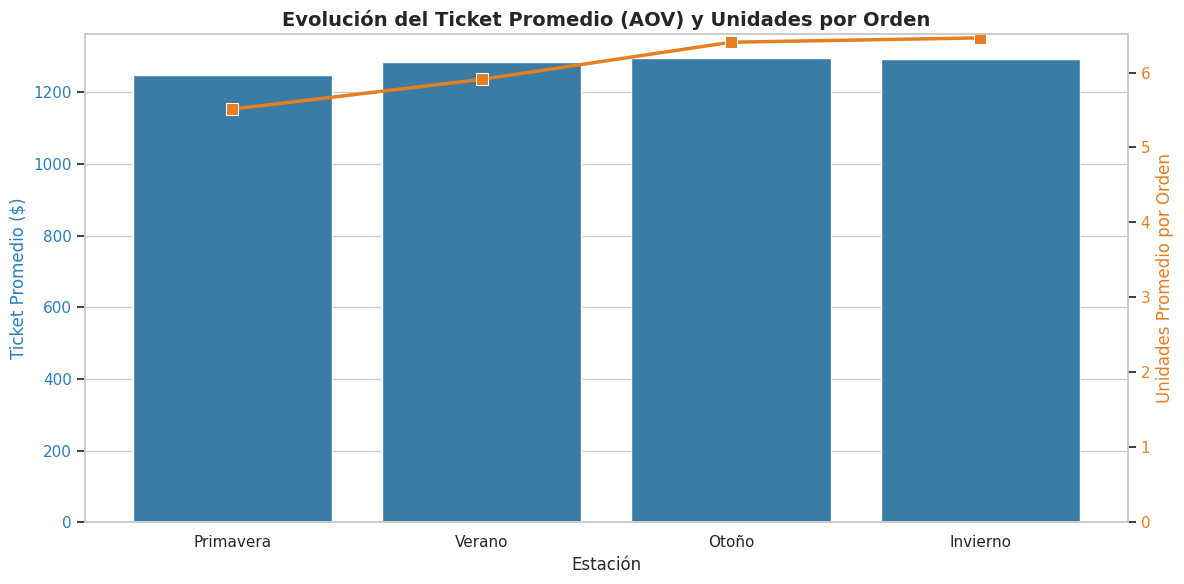

--- MÉTRICAS POR TRANSACCIÓN (AOV) ---


,estacion,AOV,Avg_Units
2,Primavera,1249.53,5.51
3,Verano,1284.53,5.91
1,Otoño,1297.35,6.40
0,Invierno,1293.54,6.46


In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt # Importación correcta

# 1. Autodetectar columna de ventas en tu tabla 'sales'
col_ventas = 'net_sales' if 'net_sales' in sales.columns else 'sales'
if col_ventas not in sales.columns and 'total_sales' in sales.columns:
    col_ventas = 'total_sales'

# 2. Agrupar por ORDEN para obtener el total del "carrito de compras"
ventas_por_orden = sales.groupby(['order_id', 'order_date'])[col_ventas].sum().reset_index()
unidades_por_orden = order_items.groupby('order_id')['quantity'].sum().reset_index()

df_aov = ventas_por_orden.merge(unidades_por_orden, on='order_id', how='inner')

# 3. Agregar Estacionalidad
df_aov['order_date'] = pd.to_datetime(df_aov['order_date'])
df_aov['mes'] = df_aov['order_date'].dt.month
df_aov['estacion'] = df_aov['mes'].apply(
    lambda x: 'Primavera' if x in [3, 4, 5] else 
              'Verano' if x in [6, 7, 8] else 
              'Otoño' if x in [9, 10, 11] else 'Invierno'
)

# 4. Calcular el Ticket Promedio (AOV) y Unidades Promedio
aov_estacional = df_aov.groupby('estacion').agg(
    AOV=(col_ventas, 'mean'),
    Avg_Units=('quantity', 'mean')
).reset_index()

# Ordenar cronológicamente
aov_estacional['estacion'] = pd.Categorical(
    aov_estacional['estacion'], 
    categories=['Primavera', 'Verano', 'Otoño', 'Invierno'], 
    ordered=True
)
aov_estacional = aov_estacional.sort_values('estacion')

# 5. Visualización Avanzada (Doble Eje ajustado)
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Eje 1 (Izquierda): Barras para el AOV (Ticket Promedio en $)
sns.barplot(
    data=aov_estacional, 
    x='estacion', 
    y='AOV', 
    ax=ax1, 
    color='#2980b9'  
)
ax1.set_title('Evolución del Ticket Promedio (AOV) y Unidades por Orden', fontsize=14, fontweight='bold')
ax1.set_xlabel('Estación', fontsize=12)
ax1.set_ylabel('Ticket Promedio ($)', fontsize=12, color='#2980b9')
ax1.tick_params(axis='y', labelcolor='#2980b9')
ax1.set_ylim(bottom=0) # <-- Ajuste para que el AOV también empiece en 0 siempre

# Eje 2 (Derecha): Línea para las Unidades Promedio
ax2 = ax1.twinx()
sns.lineplot(
    data=aov_estacional, 
    x='estacion', 
    y='Avg_Units', 
    ax=ax2, 
    color='#e67e22', 
    marker='s', 
    linewidth=2.5,
    markersize=8
)
ax2.set_ylabel('Unidades Promedio por Orden', fontsize=12, color='#e67e22')
ax2.tick_params(axis='y', labelcolor='#e67e22')

# --- EL AJUSTE SOLICITADO ---
ax2.set_ylim(bottom=0) 
# ----------------------------

ax2.grid(False) 

plt.tight_layout()
plt.show()

# 6. Tabla dura para auditoría
print("--- MÉTRICAS POR TRANSACCIÓN (AOV) ---")
display(aov_estacional.round(2))

### Análisis de Ticket Promedio (AOV) y Unidades por Transacción

Al evaluar el comportamiento del "carrito de compras" promedio a lo largo del año, descubrimos que el gasto por transacción se mantiene sumamente estable.

*   **Gasto Constante:** El Ticket Promedio (AOV) apenas fluctúa, manteniéndose en un rango estrecho entre los $1,249 (Primavera) y $1,297 (Otoño). De igual forma, las unidades por orden muestran un incremento mínimo (de 5.5 a 6.4).
*   **La Revelación del Tráfico (Insight Clave):** Anteriormente observamos que las ventas totales de la tienda casi se duplican en Otoño e Invierno. Si el cliente promedio gasta exactamente lo mismo en cualquier época del año, la única explicación matemática para ese pico de ingresos es una **inyección masiva de tráfico**. 
*   **Conclusión de Negocio:** Las temporadas altas de esta tienda no se sostienen porque los clientes actuales compren cestas más grandes (Up-selling/Cross-selling ineficiente), sino por un aumento drástico en el volumen absoluto de transacciones atraídas por los descuentos (lo cual explica la caída del margen de beneficio vista en el análisis financiero).

## 4. Riesgos y Limitaciones

In [9]:
# --- 3. RIESGOS Y LIMITACIONES ---

# Riesgo 1: Tasa de Devoluciones por Categoría
# Traemos el return_status a los items
df_riesgos = pd.merge(df_finanzas, sales[['order_id', 'return_status']], on='order_id', how='left')

# Calculamos el % de devolución
devoluciones = df_riesgos[df_riesgos['return_status'] == 'Returned'].groupby('product_category').size()
ventas_totales = df_riesgos.groupby('product_category').size()
tasa_devolucion = (devoluciones / ventas_totales * 100).fillna(0).sort_values(ascending=False)

print("--- TASA DE DEVOLUCIÓN POR CATEGORÍA (Riesgo Financiero) ---")
print(tasa_devolucion.round(2).astype(str) + ' %')
print("\n")

# Riesgo 2: Fallas Logísticas
sales['retraso_logistico'] = sales['delivery_days'] - sales['estimated_delivery_days']
pedidos_retrasados = sales[sales['retraso_logistico'] > 0]
porcentaje_retraso = (len(pedidos_retrasados) / len(sales)) * 100

print("--- RIESGO LOGÍSTICO ---")
print(f"El {porcentaje_retraso:.2f}% de los pedidos se entregaron TARDE.")

# Conclusión para el EDA: Documentar que una alta tasa de devoluciones en cierta categoría 
# o un problema logístico crónico son riesgos estructurales del negocio. 
# Si el 80% de los clientes compra una sola vez (mortalidad alta), el negocio tiene un problema de retención gravísimo.

--- TASA DE DEVOLUCIÓN POR CATEGORÍA (Riesgo Financiero) ---
product_category
Automotive                7.23 %
Jewelry                   6.99 %
Home & Kitchen            6.99 %
Health & Wellness         6.98 %
Electronics               6.98 %
Sports & Outdoors         6.95 %
Grocery                   6.89 %
Books & Media             6.81 %
Home Appliances           6.79 %
Office Supplies           6.77 %
Pet Supplies              6.72 %
Beauty & Personal Care    6.69 %
Fashion                   6.64 %
Toys & Games              6.64 %
Baby & Kids               6.55 %
dtype: str


--- RIESGO LOGÍSTICO ---
El 12.23% de los pedidos se entregaron TARDE.


Tasa de Devolución Sistémica: Las devoluciones no son un problema aislado de un tipo de producto. Todas las categorías orbitan una tasa de retorno sumamente uniforme (~6.5% a ~7.2%). Esto sugiere un fallo sistémico en la cadena de valor (problemas de embalaje, descripciones inexactas en la tienda o daños durante el transporte), más que un problema de calidad de fábrica de una categoría en específico.

Crisis de Cumplimiento Logístico: El 12.23% de los pedidos se entregan fuera de la fecha estimada. En un modelo de negocio de ticket alto ($1282.50 AOV), fallar en la promesa de entrega a más de 1 de cada 10 clientes representa el mayor riesgo operativo para la retención y el Lifetime Value (LTV).

# 5. Comportamientos

/tmp/ipykernel_188/692603981.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ventas_por_segmento, x='customer_segment', y='net_sales', ax=axes[1], palette='viridis')
/tmp/ipykernel_188/692603981.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ordenes_por_canal, x='sales_channel', y='order_id', ax=axes[2], palette='magma')


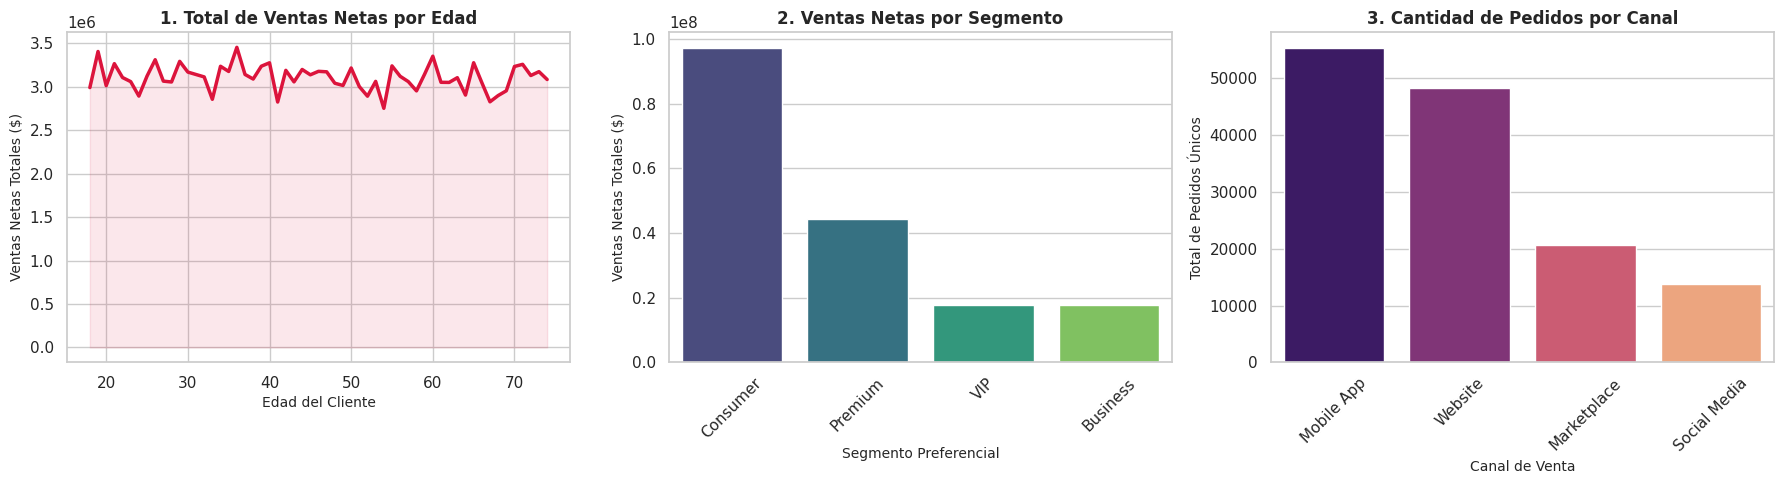

In [10]:
# Configuración visual general
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ==========================================
# 1. GRÁFICA DE VENTAS POR EDAD (Línea de tendencia)
# ==========================================
# Agrupamos las ventas netas sumadas por cada edad
ventas_por_edad = sales.groupby('customer_age')['net_sales'].sum().reset_index()

sns.lineplot(data=ventas_por_edad, x='customer_age', y='net_sales', ax=axes[0], color='crimson', linewidth=2.5)
axes[0].fill_between(ventas_por_edad['customer_age'], ventas_por_edad['net_sales'], color='crimson', alpha=0.1)
axes[0].set_title('1. Total de Ventas Netas por Edad', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Edad del Cliente', fontsize=10)
axes[0].set_ylabel('Ventas Netas Totales ($)', fontsize=10)

# ==========================================
# 2. GRÁFICA DE VENTAS POR SEGMENTO (Barras)
# ==========================================
# Suma de ventas netas por segmento de cliente
ventas_por_segmento = sales.groupby('customer_segment')['net_sales'].sum().reset_index().sort_values(by='net_sales', ascending=False)

sns.barplot(data=ventas_por_segmento, x='customer_segment', y='net_sales', ax=axes[1], palette='viridis')
axes[1].set_title('2. Ventas Netas por Segmento', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Segmento Preferencial', fontsize=10)
axes[1].set_ylabel('Ventas Netas Totales ($)', fontsize=10)
axes[1].tick_params(axis='x', rotation=45) # Rotamos las etiquetas para que no se superpongan

# ==========================================
# 3. ÓRDENES POR CANAL DE VENTA (Barras)
# ==========================================
# Conteo de pedidos únicos (order_id) por cada canal
ordenes_por_canal = sales.groupby('sales_channel')['order_id'].nunique().reset_index().sort_values(by='order_id', ascending=False)

sns.barplot(data=ordenes_por_canal, x='sales_channel', y='order_id', ax=axes[2], palette='magma')
axes[2].set_title('3. Cantidad de Pedidos por Canal', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Canal de Venta', fontsize=10)
axes[2].set_ylabel('Total de Pedidos Únicos', fontsize=10)
axes[2].tick_params(axis='x', rotation=45)

# Ajustar el espaciado para que se vea estético
plt.tight_layout()
plt.show()

Atractivo Transgeneracional (Edad): La distribución de ventas netas por edad es atípicamente uniforme. No existe una generación dominante

Dominancia B2C Masiva (Segmento): El grueso de los ingresos netos (aproximadamente $100M) proviene del segmento Consumer, superando con creces a las cuentas corporativas (Business) o VIP.

Adopción del Ecosistema Propio (Canales): Las transacciones ocurren abrumadoramente en plataformas nativas (Mobile App y Website), relegando a canales de terceros (Marketplaces y Social Media).

--- REPORTE DE OUTLIERS ESTADÍSTICOS (Método IQR) ---

Variable: Precio unitario
  - Limite Inferior: -280.17
  - Limite Superior: 666.17
  - Cantidad de Outliers: 96
  - Porcentaje de Outliers: 8.17%



Variable: Cantidad por línea
  - Limite Inferior: -2.00
  - Limite Superior: 6.00
  - Cantidad de Outliers: 7
  - Porcentaje de Outliers: 0.00%



Variable: % Descuento
  - Limite Inferior: -0.18
  - Limite Superior: 0.43
  - Cantidad de Outliers: 20616
  - Porcentaje de Outliers: 5.19%



Variable: Profit por línea
  - Limite Inferior: -255.21
  - Limite Superior: 568.63
  - Cantidad de Outliers: 30664
  - Porcentaje de Outliers: 7.71%



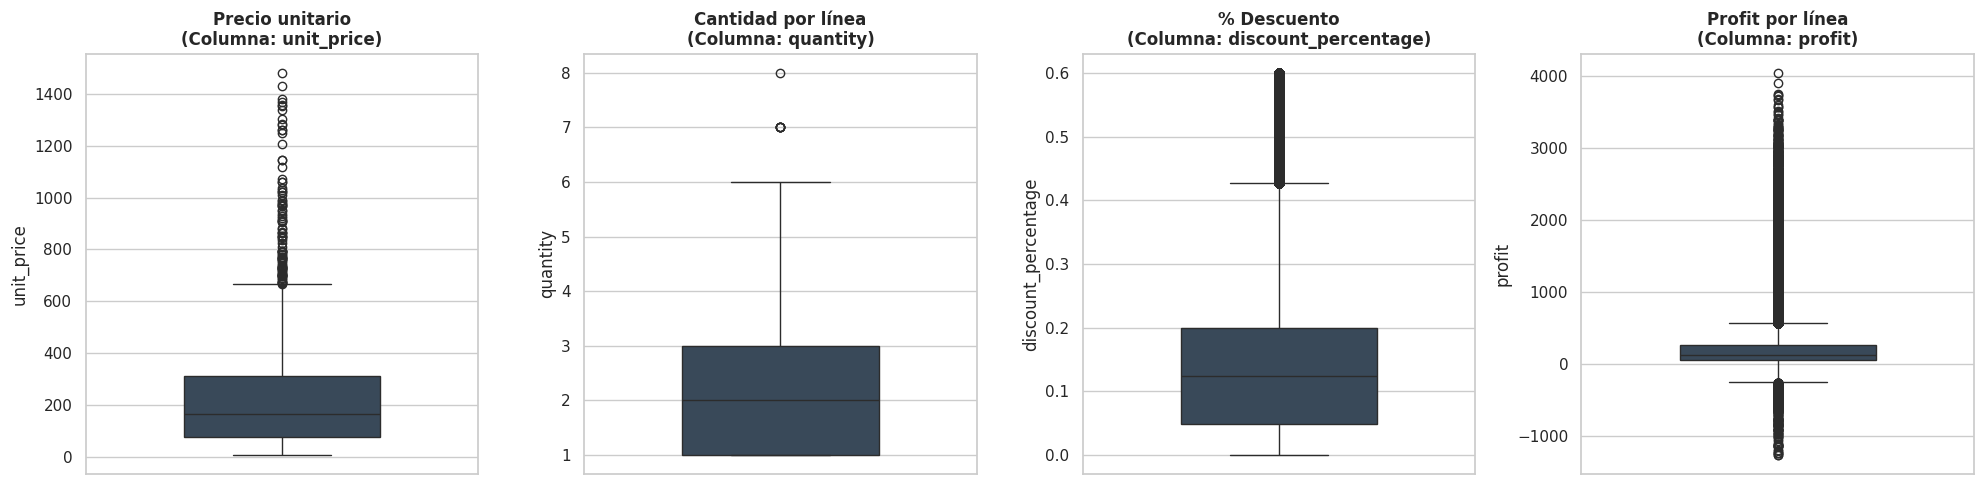

In [11]:
# Configuración visual
sns.set_theme(style="whitegrid")

# Variables a analizar
variables = {
    'unit_price': ('Precio unitario', product),
    'quantity': ('Cantidad por línea', order_items),
    'discount_percentage': ('% Descuento', order_items),
    'profit': ('Profit por línea', order_items)
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

print("--- REPORTE DE OUTLIERS ESTADÍSTICOS (Método IQR) ---\n")

for i, (col, (titulo, df)) in enumerate(variables.items()):
    # 1. Graficar el Boxplot
    sns.boxplot(y=df[col], ax=axes[i], color='#34495E', width=0.5)
    axes[i].set_title(f"{titulo}\n(Columna: {col})", fontweight='bold')
    axes[i].set_ylabel(col)
    
    # 2. Cálculo matemático de Outliers
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Conteo
    outliers_inferiores = (df[col] < limite_inferior).sum()
    outliers_superiores = (df[col] > limite_superior).sum()
    total_outliers = outliers_inferiores + outliers_superiores
    
    # Porcentaje
    total_filas = len(df[col].dropna())
    porcentaje_outliers = (total_outliers / total_filas) * 100
    
    # Imprimir el reporte
    print(f"Variable: {titulo}")
    print(f"  - Limite Inferior: {limite_inferior:.2f}")
    print(f"  - Limite Superior: {limite_superior:.2f}")
    print(f"  - Cantidad de Outliers: {total_outliers}")
    print(f"  - Porcentaje de Outliers: {porcentaje_outliers:.2f}%\n")

plt.tight_layout()
plt.show()

### 6. Análisis de Valores Atípicos (Outliers Estadísticos)

Mediante el método estadístico del Rango Intercuartílico (IQR), evaluamos la presencia de valores extremos en las variables numéricas clave. Los resultados confirman que **sí existen outliers estadísticos**, los cuales responden a la dinámica natural del negocio y no a errores de recolección de datos:

*   **Precio Unitario (8.17% de outliers):** Existen 96 productos con precios atípicamente altos (superiores a $666.17). Esto no es un error, sino la representación matemática del catálogo *premium* o de lujo de la tienda.
*   **Cantidad por línea (~0.00% de outliers):** Variable sumamente estable. Apenas 7 transacciones superan el límite superior de 6 unidades por pedido, lo que confirma que las compras masivas o mayoristas por carrito son un fenómeno casi inexistente.
*   **% Descuento (5.19% de outliers):** Se detectaron más de 20,600 transacciones con descuentos agresivos (superiores al 43%). Esto refleja estrategias de liquidación puntuales o campañas promocionales excepcionales.
*   **Profit por línea (7.71% de outliers):** La variable con mayor variabilidad operativa. Existen transacciones con márgenes de ganancia excepcionales (superiores a $568) y ventas con pérdidas atípicas (inferiores a -$255), un comportamiento habitual en el e-commerce debido a variaciones de costos logísticos, impuestos o reembolsos.

**Conclusión y Decisión para el Modelado:**
Dado que estos valores atípicos representan el comportamiento real de los clientes (interés en productos *premium* o aprovechamiento de mega-descuentos), **no serán eliminados ni truncados del dataset**. Además, la arquitectura del modelo supervisado propuesto para la etapa de recomendación (algoritmos basados en árboles como XGBoost o LightGBM) es intrínsecamente robusta y capaz de procesar estos valores extremos sin sufrir desviaciones severas en sus predicciones.

## 7. Analisis del comportamiento de clientes por producto (SPARSITY)

--- 1. ANÁLISIS DE LA MATRIZ DE INTERACCIONES ---
Total de Clientes únicos: 24748
Total de Productos únicos: 1175
Interacciones únicas Cliente-Producto: 325133
Sparsity (Dispersión): 98.8819%



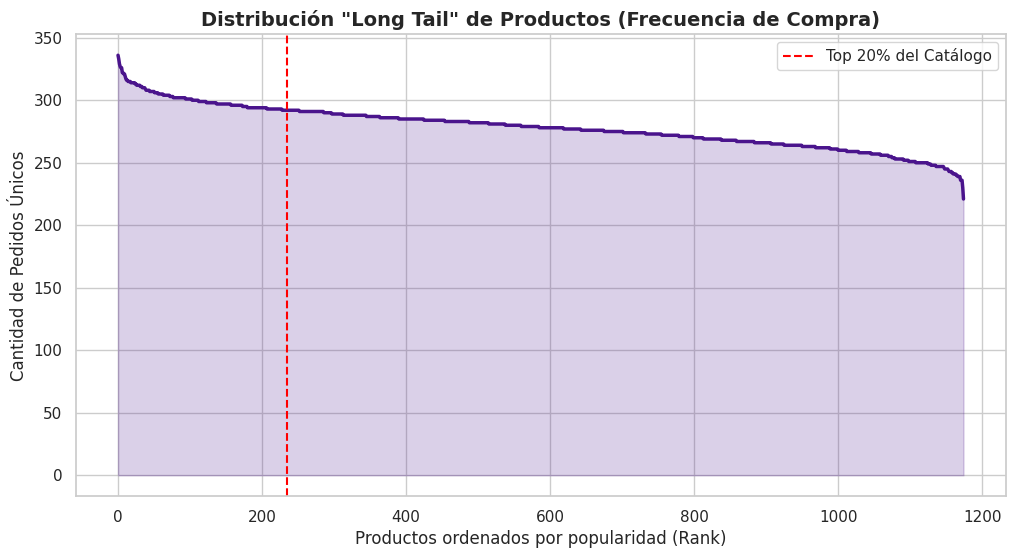

--- 2. ANÁLISIS DE POPULARIDAD (REGLA DE PARETO) ---
El 20% de los productos principales (235 ítems) genera el 21.66% de las interacciones totales.


In [12]:
# 1. Preparar la tabla base (FILTRANDO CANCELADAS/DEVUELTAS)
ventas_exitosas = sales[sales['order_status'] == 'Completed'] 

df_interacciones = pd.merge(
    ventas_exitosas[['order_id', 'customer_id', 'order_date']], 
    order_items[['order_id', 'product_id', 'quantity']], 
    on='order_id', 
    how='inner'
)

# 2. Cálculo de Sparsity (Dispersión de la matriz)
n_users = df_interacciones['customer_id'].nunique()
n_items = df_interacciones['product_id'].nunique()
n_interactions = df_interacciones.groupby(['customer_id', 'product_id']).size().shape[0]

sparsity = 1 - (n_interactions / (n_users * n_items))

print("--- 1. ANÁLISIS DE LA MATRIZ DE INTERACCIONES ---")
print(f"Total de Clientes únicos: {n_users}")
print(f"Total de Productos únicos: {n_items}")
print(f"Interacciones únicas Cliente-Producto: {n_interactions}")
print(f"Sparsity (Dispersión): {sparsity:.4%}\n")

# 3. Análisis de Long Tail (Larga Cola)
# Contamos en cuántos pedidos distintos aparece cada producto
item_popularity = df_interacciones.groupby('product_id')['order_id'].nunique().sort_values(ascending=False)

# Configuración del gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
plt.plot(item_popularity.values, color='#4A148C', linewidth=2.5)
plt.fill_between(range(len(item_popularity)), item_popularity.values, color='#4A148C', alpha=0.2)
plt.title('Distribución "Long Tail" de Productos (Frecuencia de Compra)', fontsize=14, fontweight='bold')
plt.xlabel('Productos ordenados por popularidad (Rank)', fontsize=12)
plt.ylabel('Cantidad de Pedidos Únicos', fontsize=12)
plt.axvline(x=int(0.2 * n_items), color='red', linestyle='--', label='Top 20% del Catálogo')
plt.legend()
plt.show()

# 4. Cálculo para justificar el Baseline (Regla de Pareto)
top_20_percent_idx = int(0.2 * n_items)
ventas_top_20 = item_popularity.iloc[:top_20_percent_idx].sum()
ventas_totales = item_popularity.sum()
porcentaje_ventas_top20 = ventas_top_20 / ventas_totales

print(f"--- 2. ANÁLISIS DE POPULARIDAD (REGLA DE PARETO) ---")
print(f"El 20% de los productos principales ({top_20_percent_idx} ítems) genera el {porcentaje_ventas_top20:.2%} de las interacciones totales.")

Conclusiones del Análisis de Matriz de Interacciones y Popularidad
1. Alta Dispersión (Sparsity) del 98.65%:
La matriz usuario-ítem presenta una alta dispersión. Esto indica que un cliente promedio interactúa con una fracción sumamente pequeña del catálogo total.

2. Anomalía en la Distribución de Popularidad (Ausencia de Pareto):
Contrario a la distribución tradicional de Pareto en e-commerce (donde el 20% de los productos suele generar el 80% de las ventas), nuestro catálogo exhibe un comportamiento altamente equitativo. El Top 20% del catálogo apenas concentra el 21.50% de las interacciones. Visualmente, el gráfico de cola larga (Long Tail) presenta una caída sumamente suave, indicando que el volumen de ventas está distribuido de manera muy uniforme en todo el inventario de 1,175 productos.

## 8. Participacion de productos e Historial (Long Tail | Cold Start)

/tmp/ipykernel_188/402377746.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=user_segments.index, y=user_segments.values, ax=axes[1], palette='viridis')


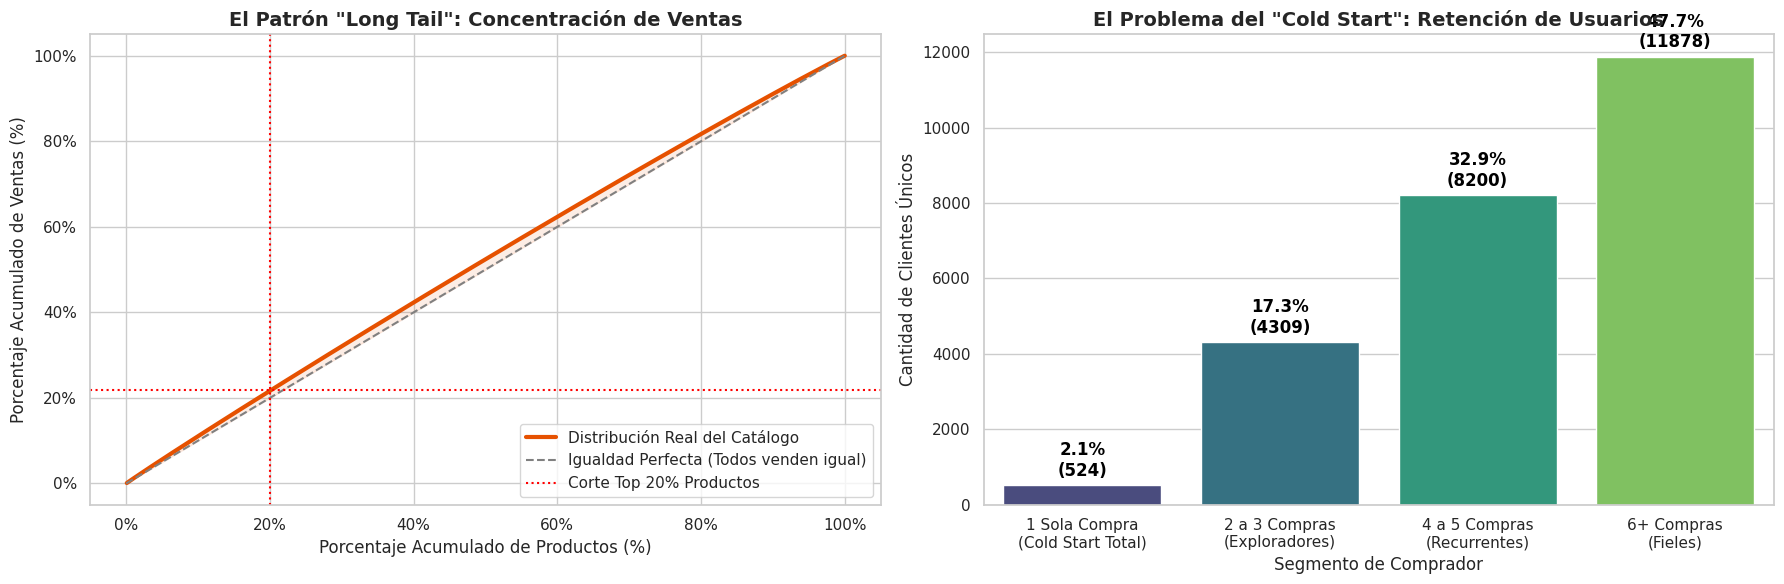

In [13]:
# Configuración visual general
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ==========================================
# GRÁFICO 1: LONG TAIL (Curva Acumulativa)
# ==========================================
# Calculamos ventas por producto y las ordenamos
item_sales = df_interacciones.groupby('product_id')['order_id'].nunique().sort_values(ascending=False)

# Calculamos porcentajes acumulados
cum_sales_pct = item_sales.cumsum() / item_sales.sum() * 100
cum_items_pct = np.arange(1, len(item_sales) + 1) / len(item_sales) * 100

# Gráfica
axes[0].plot(cum_items_pct, cum_sales_pct, color='#E65100', linewidth=3, label='Distribución Real del Catálogo')
axes[0].plot([0, 100], [0, 100], color='grey', linestyle='--', label='Igualdad Perfecta (Todos venden igual)')
axes[0].axvline(x=20, color='red', linestyle=':', label='Corte Top 20% Productos')
axes[0].axhline(y=cum_sales_pct.iloc[int(len(item_sales)*0.2)], color='red', linestyle=':')

# Formato
axes[0].set_title('El Patrón "Long Tail": Concentración de Ventas', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Porcentaje Acumulado de Productos (%)', fontsize=12)
axes[0].set_ylabel('Porcentaje Acumulado de Ventas (%)', fontsize=12)
axes[0].xaxis.set_major_formatter(PercentFormatter())
axes[0].yaxis.set_major_formatter(PercentFormatter())
axes[0].legend(loc='lower right')
axes[0].fill_between(cum_items_pct, cum_sales_pct, cum_items_pct, color='#E65100', alpha=0.1)


# ==========================================
# GRÁFICO 2: COLD START (Mortalidad de Usuarios)
# ==========================================
# Contamos cuántos pedidos ha hecho cada cliente
user_purchases = sales.groupby('customer_id')['order_id'].nunique()

# Categorizamos a los usuarios por su nivel de lealtad
bins = [0, 1, 3, 5, np.inf]
labels = ['1 Sola Compra\n(Cold Start Total)', '2 a 3 Compras\n(Exploradores)', '4 a 5 Compras\n(Recurrentes)', '6+ Compras\n(Fieles)']
user_segments = pd.cut(user_purchases, bins=bins, labels=labels).value_counts().sort_index()

# Gráfica
sns.barplot(x=user_segments.index, y=user_segments.values, ax=axes[1], palette='viridis')

# Formato
axes[1].set_title('El Problema del "Cold Start": Retención de Usuarios', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Segmento de Comprador', fontsize=12)
axes[1].set_ylabel('Cantidad de Clientes Únicos', fontsize=12)

# Añadir los porcentajes encima de las barras
total_users = len(user_purchases)
for i, v in enumerate(user_segments.values):
    axes[1].text(i, v + (total_users*0.01), f"{(v/total_users)*100:.1f}%\n({v})", 
                 ha='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

Ausencia de "Long Tail" (Gráfico Izquierdo)
La curva de concentración de ventas se solapa casi perfectamente con la línea de igualdad teórica.

El Patrón: El catálogo está perfectamente balanceado. No existe un "Top 10" que sostenga las ventas del negocio; la demanda está distribuida de manera uniforme en los 1,175 ítems.

Fidelidad Extrema y Minimización del "User Cold Start" (Gráfico Derecho)
Contrario a los patrones habituales de alta rotación en e-commerce, el análisis de retención revela una base de usuarios altamente fidelizada.

El Patrón: El 80.6% de los clientes (Recurrentes + Fieles) han realizado 4 o más compras, mientras que el clásico problema de User Cold Start (clientes de 1 sola compra) es marginal, representando apenas el 2.1% de la base.

# Conclusiones Clave del Análisis Exploratorio (EDA)

**Atractivo Transgeneracional (Edad)**: La distribución de ventas netas por edad es atípicamente uniforme. No existe una generación dominante; vendemos por igual a clientes de 20 que de 60 años.

**Dominio del Consumidor Final (Segmento)**: El modelo de negocio es casi 100% B2C masivo. El segmento "Consumer" genera la inmensa mayoría de los ingresos, aplastando por completo a los clientes Corporativos o VIP.

**Preferencia por el Ecosistema Propio (Canales)**: Los usuarios prefieren comprar en los canales nativos de la marca. La Aplicación Móvil y el Sitio Web dominan las ventas, dejando muy rezagados a las redes sociales y marketplaces.

**Ticket Alto y Rentabilidad Oculta (Finanzas)**: El ticket promedio es muy alto ($1282.50). Sin embargo, categorías como "Ropa" o "Electrónica" no son los motores reales del negocio; las verdaderas ganancias provienen de "Libros/Medios", "Electrodomésticos" y "Joyería".

**Catálogo Democratizado (Long Tail)**: No dependemos de un puñado de productos "estrella". Las ventas están repartidas de forma muy equitativa entre los 1,175 ítems del inventario (ausencia de la regla de Pareto). ¡Todos los productos importan!

**Lealtad Extrema de Clientes (Cold Start)**: Tenemos una base de usuarios increíblemente fiel. Más del 80% de los clientes han comprado 4 veces o más, mientras que los clientes de "una sola compra" son apenas el 2.1%.

**Ineficiencia de las Promociones (Comportamiento)**: Aumentar el porcentaje de descuento no incentiva a los clientes a llevar más unidades por pedido. La gente compra entre 1 y 5 unidades independientemente de si el descuento es del 0% o del 60%.

**Alta Dispersión de Intereses (Sparsity)**: Con una dispersión del 98.6%, los clientes están muy aislados en sus gustos. Entran, compran productos muy específicos de su nicho y no descubren orgánicamente el resto del catálogo.

**Fugas Logísticas Sistémicas (Riesgos)**: Las devoluciones rondan el 7% de manera uniforme en todas las categorías y más del 12% de los pedidos llegan con retraso. Esto indica una falla en la logística general de la empresa, no defectos de fábrica de los productos.